In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
file_path = "mental_health.csv"
df = pd.read_csv(file_path)


df.columns = df.columns.str.strip()

df = df.drop("Person_ID", axis=1)

In [3]:
BG = "#0f1117"
PANEL = "#1c1f26"
TEXT = "#e6e6e6"

plt.style.use("default")
target = "Depression"

In [4]:
df.head()

,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2000 non-null   int64  
 1   Gender                    2000 non-null   object 
 2   Occupation                2000 non-null   object 
 3   Daily_Screen_Time         2000 non-null   float64
 4   Social_Media_Usage        2000 non-null   float64
 5   Night_Usage               2000 non-null   int64  
 6   Sleep_Hours               2000 non-null   float64
 7   Stress_Level              2000 non-null   int64  
 8   Work_Study_Hours          2000 non-null   float64
 9   Physical_Activity         2000 non-null   object 
 10  Social_Interaction_Score  2000 non-null   int64  
 11  Caffeine_Intake           2000 non-null   int64  
 12  Smoking                   2000 non-null   int64  
 13  Alcohol                   2000 non-null   int64  
 14  Depressi

In [6]:
df.describe()

,Age,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,37.694000,6.943150,4.436400,0.489500,6.00765,5.409500,7.005650,5.488000,2.029500,0.492000,0.513000,0.499000,0.505500,0.515500
std,12.614195,2.882415,2.011725,0.500015,1.70631,2.885129,2.846442,2.885484,1.432709,0.500061,0.499956,0.500124,0.500095,0.499885
min,16.000000,2.000000,1.000000,0.000000,3.00000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,4.500000,2.700000,0.000000,4.60000,3.000000,4.500000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,38.000000,6.800000,4.400000,0.000000,6.00000,5.000000,7.100000,6.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000
75%,49.000000,9.400000,6.200000,1.000000,7.50000,8.000000,9.400000,8.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,59.000000,12.000000,8.000000,1.000000,9.00000,10.000000,12.000000,10.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Checking data types

In [7]:
df.dtypes

,0
Age,int64
Gender,object
Occupation,object
Daily_Screen_Time,float64
Social_Media_Usage,float64
Night_Usage,int64
Sleep_Hours,float64
Stress_Level,int64
Work_Study_Hours,float64
Physical_Activity,object


In [8]:
df.columns

Index(['Age', 'Gender', 'Occupation', 'Daily_Screen_Time',
       'Social_Media_Usage', 'Night_Usage', 'Sleep_Hours', 'Stress_Level',
       'Work_Study_Hours', 'Physical_Activity', 'Social_Interaction_Score',
       'Caffeine_Intake', 'Smoking', 'Alcohol', 'Depression', 'Anxiety',
       'Burnout'],
      dtype='object')

In [9]:
missing_values = df.isnull().sum()
missing_values

,0
Age,0
Gender,0
Occupation,0
Daily_Screen_Time,0
Social_Media_Usage,0
Night_Usage,0
Sleep_Hours,0
Stress_Level,0
Work_Study_Hours,0
Physical_Activity,0


In [11]:
duplicated_values = df.duplicated().sum()
duplicated_values

np.int64(0)

In [12]:
target_dist = df["Depression"].value_counts(normalize=True)
target_dist

,proportion
Depression,
0,0.501
1,0.499


In [13]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

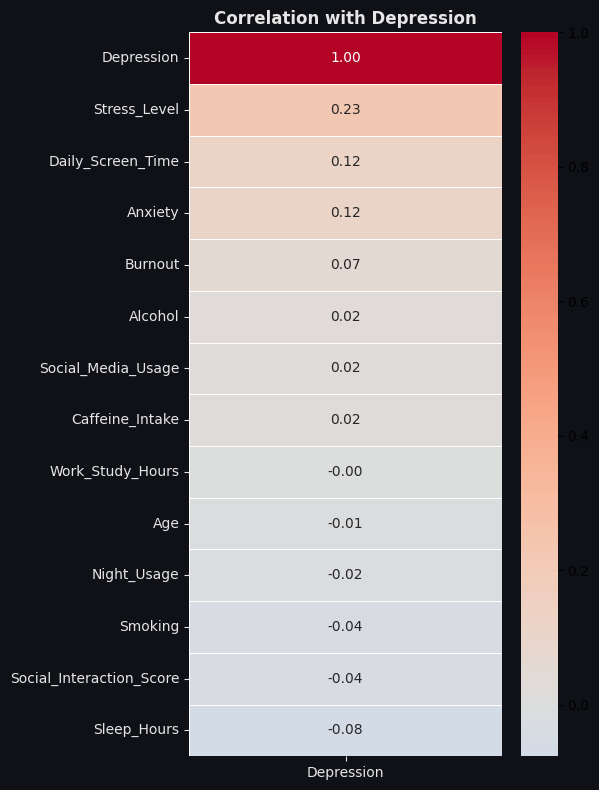

In [14]:
target = "Depression"

corr_target = numerical_df.corr(numeric_only=True)[[target]].sort_values(by=target, ascending=False)

plt.figure(figsize=(6, 8), facecolor=BG)
ax = plt.gca()
ax.set_facecolor(PANEL)

sns.heatmap(
    corr_target,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    center=0,
    cbar=True
)

ax.set_title("Correlation with Depression", color=TEXT, fontweight='bold')
ax.tick_params(colors=TEXT)

plt.tight_layout()
plt.show()

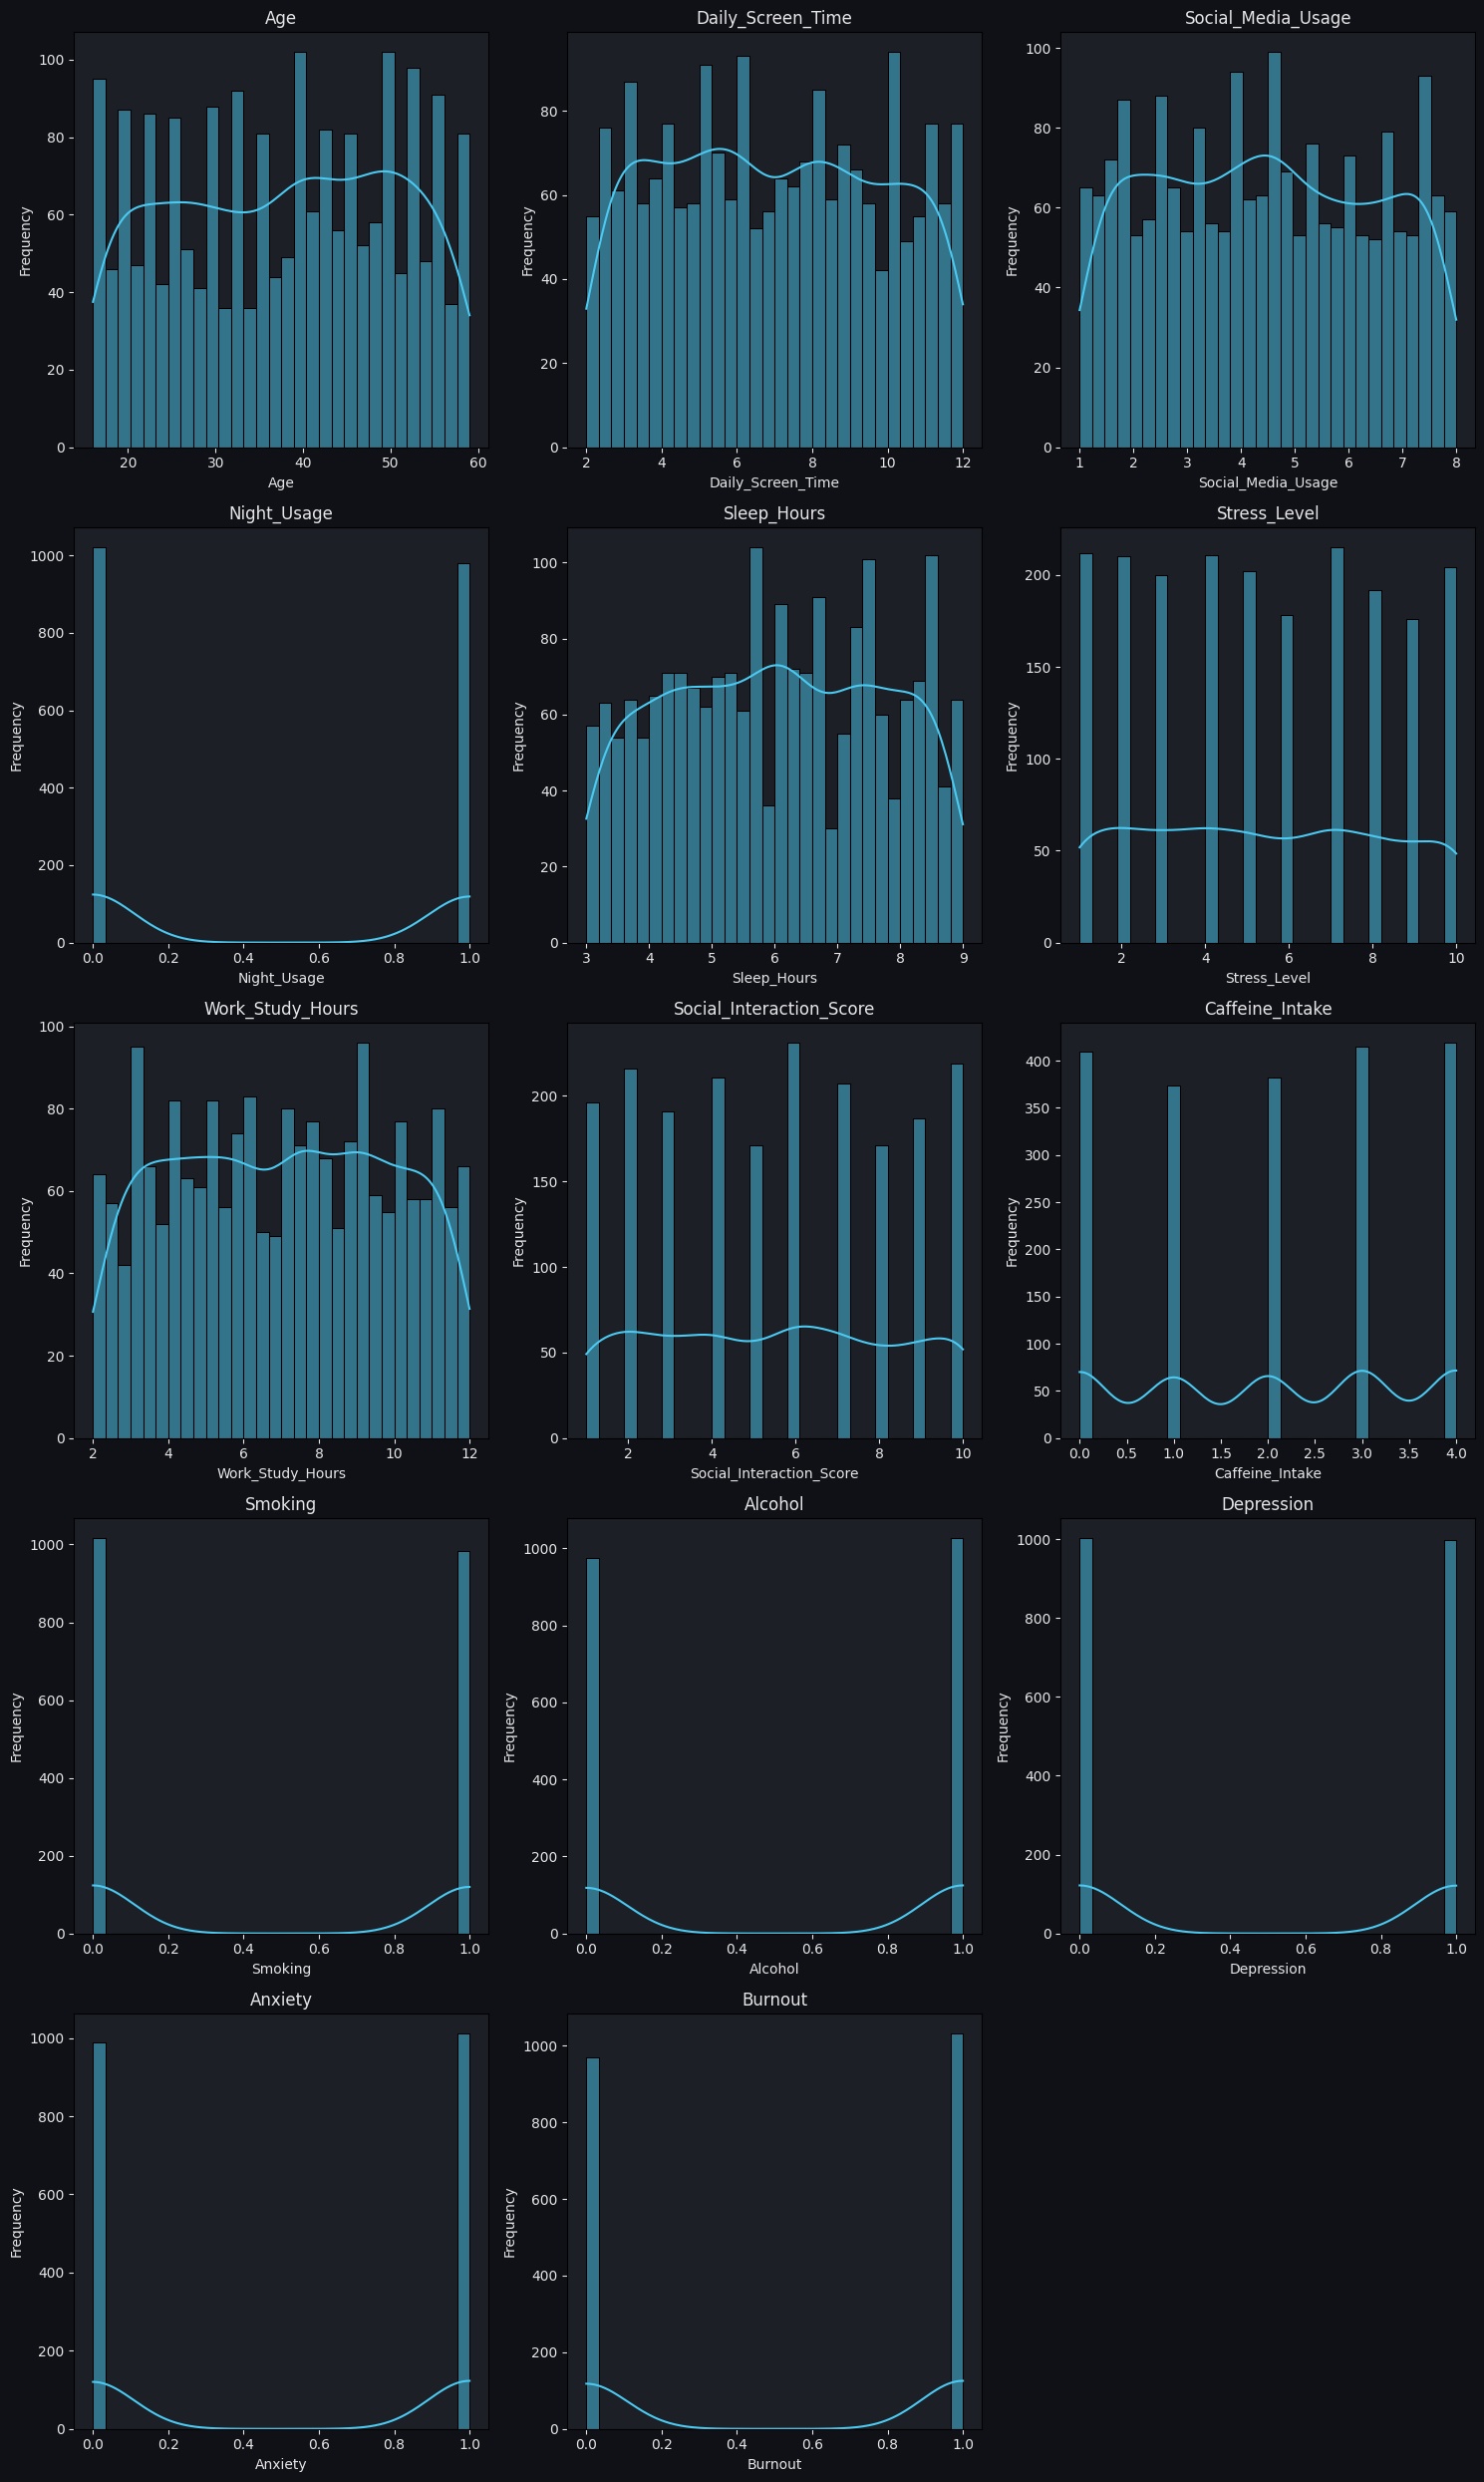

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


cols = numerical_df.columns
n = len(cols)


n_cols = 3
n_rows = int(np.ceil(n / n_cols))


fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()


fig.patch.set_facecolor(BG)

for i, col in enumerate(cols):
    ax = axes[i]

    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color="#4cc9f0",
        ax=ax
    )

    ax.set_title(f"{col}", color=TEXT)
    ax.set_xlabel(col, color=TEXT)
    ax.set_ylabel("Frequency", color=TEXT)

    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

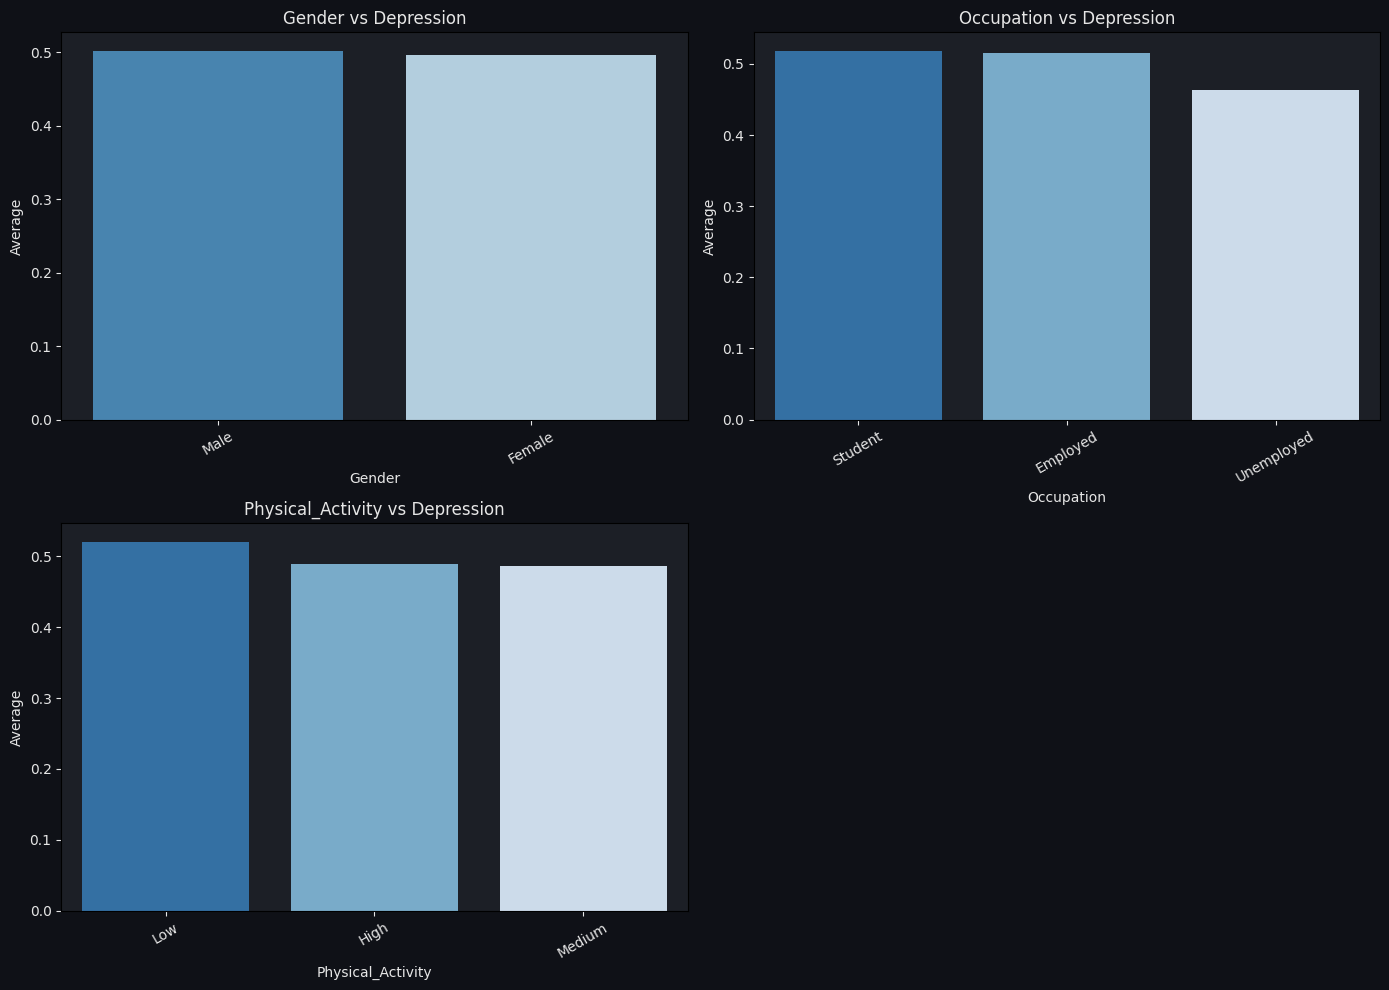

In [16]:
target_col = "Depression"


cat_cols = df.select_dtypes(include=["object", "category"]).columns

n = len(cat_cols)
n_cols = 2
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

fig.patch.set_facecolor(BG)

for i, col in enumerate(cat_cols):
    ax = axes[i]

    #
    agg = (
        df.groupby(col)[target_col]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    sns.barplot(
    data=agg,
    x=col,
    y=target_col,
    hue=col,
    palette="Blues_r",
    errorbar="ci",
    legend=False,
    ax=ax
)


    ax.set_title(f"{col} vs {target_col}", color=TEXT)
    ax.set_xlabel(col, color=TEXT)
    ax.set_ylabel("Average", color=TEXT)

    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT)
    ax.tick_params(axis='x', rotation=30)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Machine Learning
Setting up the model

In [17]:
df = pd.get_dummies(df, drop_first=True)

In [19]:
X = df.drop("Depression", axis=1)
Y = df["Depression"]


X_scaled = StandardScaler().fit_transform(X)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

Training the Model

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


rf_model = RandomForestClassifier(random_state=42)


param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
}


random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist,
                                   n_iter=50, scoring='accuracy', cv=3, verbose=1,
                                   random_state=42, n_jobs=-1)


random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Accuracy:", random_search.best_score_)

best_rf_model = random_search.best_estimator_
y_pred = best_rf_model.predict(X_test)


print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Best Cross-Validation Accuracy: 0.5987438309992434
Test Accuracy: 0.5925
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.60      0.59       198
           1       0.60      0.59      0.59       202

    accuracy                           0.59       400
   macro avg       0.59      0.59      0.59       400
weighted avg       0.59      0.59      0.59       400



Feature Importances

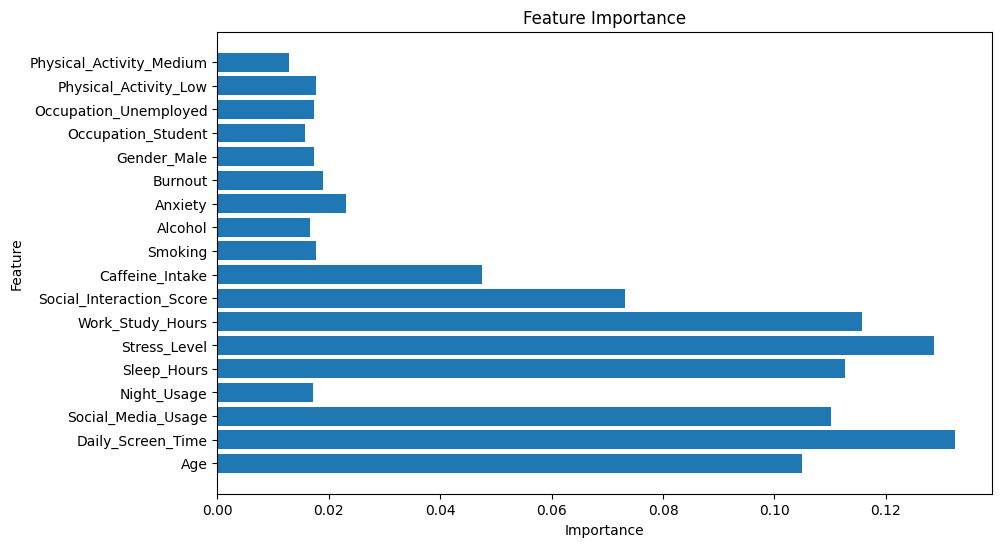

In [ ]:
# Feature Importance
feature_importances = best_rf_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(X.columns, feature_importances)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.show()